# 2.2 — Action-value Methods

---

## The sample-average estimate

The obvious way to estimate the value of an action is to average the rewards actually
received from it:

$$Q_t(a) \;\doteq\; \frac{\text{sum of rewards when } a \text{ taken prior to } t}{\text{number of times } a \text{ taken prior to } t}
\;=\; \frac{\displaystyle\sum_{i=1}^{t-1} R_i \cdot \mathbb{1}_{A_i = a}}{\displaystyle\sum_{i=1}^{t-1} \mathbb{1}_{A_i = a}}$$

with the convention $Q_t(a) = 0$ (or any default) when the denominator is zero.

By the law of large numbers, $Q_t(a) \to q_*(a)$ **as the denominator goes to
infinity**. That last clause is the catch, and it is the whole reason exploration
matters: convergence is guaranteed only for actions you keep selecting. An action
you abandon early is frozen at whatever unlucky estimate drove you away from it.

## Greedy selection

$$A_t \;\doteq\; \operatorname*{arg\,max}_a Q_t(a)$$

Greedy always exploits. It spends zero steps improving knowledge of the non-greedy
actions — and by the paragraph above, that means their estimates never recover.

## $\varepsilon$-greedy

$$A_t = \begin{cases}
\operatorname*{arg\,max}_a Q_t(a) & \text{with probability } 1-\varepsilon \\[4pt]
\text{a uniformly random action} & \text{with probability } \varepsilon
\end{cases}$$

Small, crude, and remarkably effective. Its key asymptotic property: every action is
selected infinitely often, so $Q_t(a) \to q_*(a)$ **for all $a$**, so the probability
of selecting the optimal action converges to

$$1 - \varepsilon + \frac{\varepsilon}{k}$$

which is greater than $1-\varepsilon$ but *strictly less than 1*. $\varepsilon$-greedy
never fully stops paying for exploration. Hold onto that ceiling — it explains the
crossover you will see in Section 2.3.

In [6]:
import sys, os
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
from bandit_utils import (Testbed, run_bandit, plot_pair, argmax_random_tiebreak,
                          hide, banner, RUNS, STEPS)

plt.rcParams["figure.dpi"] = 110
banner()

mode=FULL  runs=2000  steps=1000
switch with:  import os; os.environ['RL_MODE']='FULL'  (before importing)


## Watching one agent learn

Before any averaged curves, look at a *single run* of $\varepsilon$-greedy. Averaged
plots hide what individual learning actually looks like: lumpy, hesitant, and driven
by a handful of pivotal early samples.

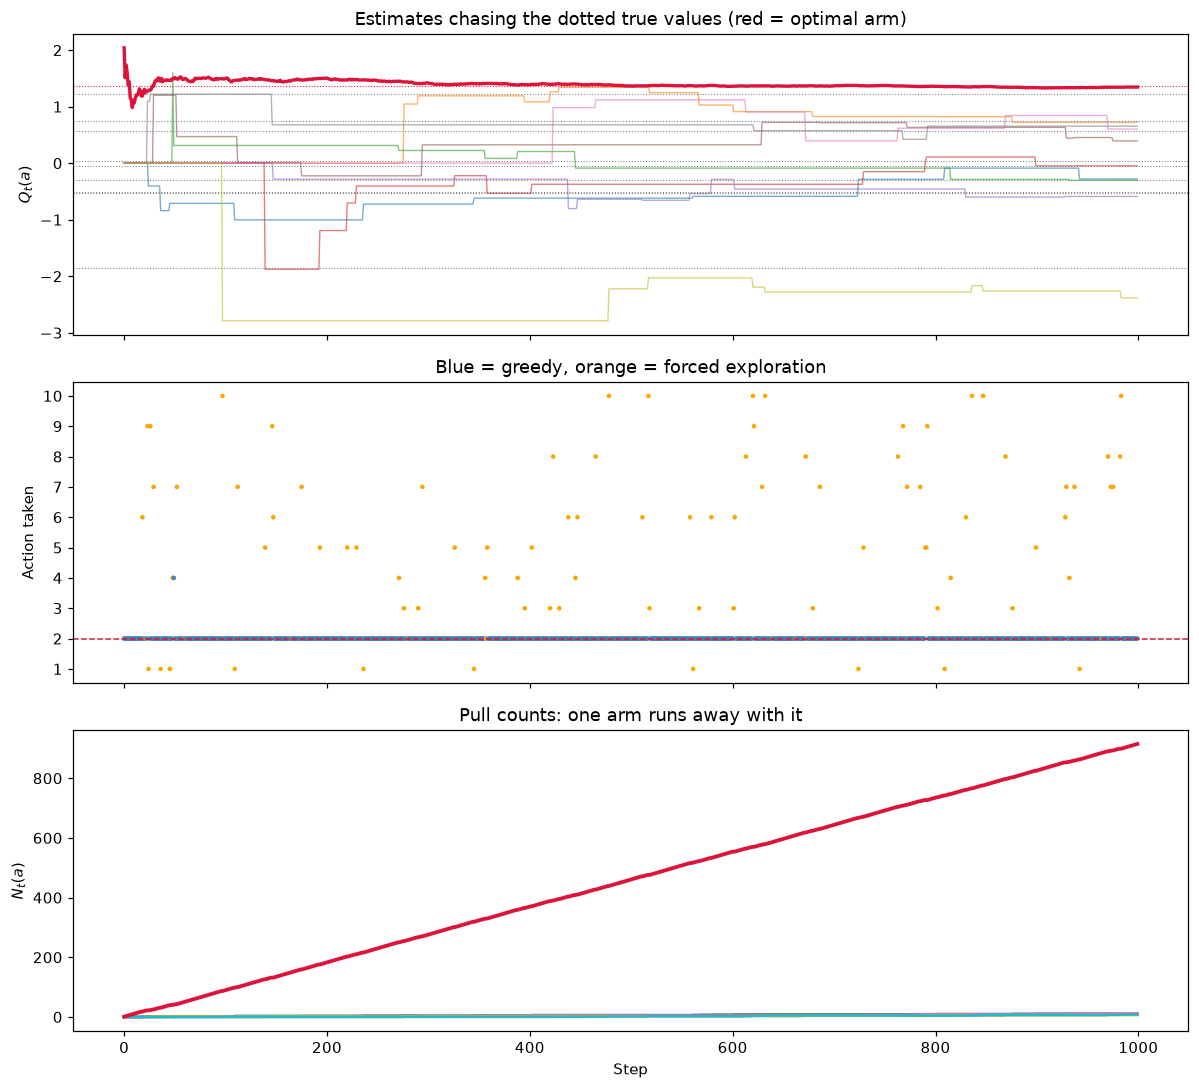

final Q: [-0.28  1.35  0.72 -0.3  -0.05 -0.59  0.39  0.6   0.65 -2.38]
true q*: [ 0.03  1.36  1.22 -0.51 -0.3  -0.53  0.57 -0.06  0.75 -1.85]
pulls  : [ 10 915  11   8  11  10  13   8   6   8]


In [7]:
def single_run(eps=0.1, steps=1000, k=10, seed=11, Q_init=0.0):
    rng = np.random.default_rng(seed)
    q_star = rng.normal(0, 1, size=k)
    Q = np.full(k, float(Q_init))
    N = np.zeros(k, dtype=int)

    hist = {"Q": [], "N": [], "action": [], "reward": [], "explored": []}
    for t in range(steps):
        explore = rng.random() < eps
        if explore:
            a = rng.integers(k)
        else:
            best = np.flatnonzero(Q == Q.max())
            a = rng.choice(best)
        r = rng.normal(q_star[a], 1.0)
        N[a] += 1
        Q[a] += (r - Q[a]) / N[a]
        hist["Q"].append(Q.copy()); hist["N"].append(N.copy())
        hist["action"].append(a); hist["reward"].append(r); hist["explored"].append(explore)
    return q_star, {kk: np.array(v) for kk, v in hist.items()}

q_star, h = single_run(eps=0.1, seed=11)
best_arm = q_star.argmax()

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

for a in range(10):
    style = dict(lw=2.2, color="crimson", zorder=5) if a == best_arm else dict(lw=0.9, alpha=0.6)
    axes[0].plot(h["Q"][:, a], **style)
    axes[0].axhline(q_star[a], ls=":", lw=0.7,
                    color="crimson" if a == best_arm else "gray")
axes[0].set_ylabel("$Q_t(a)$")
axes[0].set_title("Estimates chasing the dotted true values (red = optimal arm)")

axes[1].scatter(np.arange(len(h["action"])), h["action"] + 1, s=4,
                c=np.where(h["explored"], "orange", "steelblue"))
axes[1].axhline(best_arm + 1, color="crimson", ls="--", lw=1)
axes[1].set_ylabel("Action taken")
axes[1].set_yticks(range(1, 11))
axes[1].set_title("Blue = greedy, orange = forced exploration")

axes[2].plot(h["N"])
axes[2].plot(h["N"][:, best_arm], color="crimson", lw=2.5)
axes[2].set_ylabel("$N_t(a)$")
axes[2].set_xlabel("Step")
axes[2].set_title("Pull counts: one arm runs away with it")
plt.tight_layout(); plt.show()

print("final Q:", np.round(h['Q'][-1], 2))
print("true q*:", np.round(q_star, 2))
print("pulls  :", h['N'][-1])

Two things to notice in the middle panel:

- The blue band is nearly a solid line at one arm — greedy exploitation dominates the
  timeline. Exploration is the orange confetti, at rate $\varepsilon$.
- Every so often an orange dot at some other arm is followed by the blue band *moving*.
  That is the entire mechanism by which the agent escapes a bad commitment.

And in the bottom panel: $N_t(a)$ for the chosen arm grows linearly while everyone
else grows at $\varepsilon/k \approx 1\%$ per step. Since estimate accuracy improves as
$1/\sqrt{N}$, the agent knows its favourite arm ~30× more precisely than the others.

---

### Predict first

Now compare $\varepsilon = 0$ (pure greedy) on **the same bandit problem, same seed**.

1. Will pure greedy find the optimal arm here?
2. Its estimate $Q(a)$ for its chosen arm — will it end up above or below the true
   $q_*(a)$ of that arm? Why?

*Write your guess down (mentally or in the cell below) before running the next cell. The point is not to be right — it is to make the surprise informative when you are wrong.*

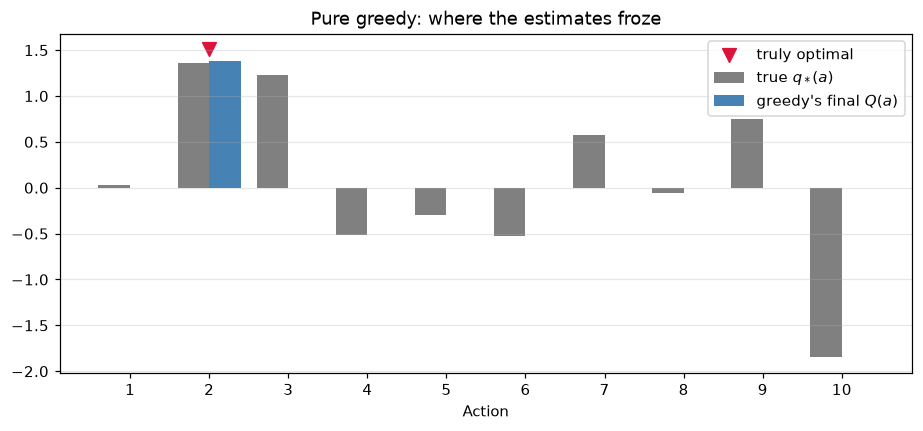

greedy locked onto arm 2 | optimal was 2
pulls: [   0 1000    0    0    0    0    0    0    0    0]


In [8]:
q0, h0 = single_run(eps=0.0, seed=11)
chosen = h0["action"][-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(np.arange(10) - 0.2, q0, 0.4, label="true $q_*(a)$", color="gray")
ax.bar(np.arange(10) + 0.2, h0["Q"][-1], 0.4, label="greedy's final $Q(a)$",
       color="steelblue")
ax.scatter([q0.argmax()], [q0.max() + 0.15], marker="v", color="crimson", s=80,
           label="truly optimal")
ax.set_xticks(range(10)); ax.set_xticklabels(range(1, 11))
ax.set_xlabel("Action"); ax.legend(); ax.grid(alpha=0.3, axis="y")
ax.set_title("Pure greedy: where the estimates froze")
plt.show()

print("greedy locked onto arm", chosen + 1, "| optimal was", q0.argmax() + 1)
print("pulls:", h0['N'][-1])

hide('''Greedy commits to whichever arm gave a lucky first sample and then never
revisits the others &mdash; look at the pull counts: nine arms sit at exactly 1.
Those nine Q values are frozen at a single noisy sample forever.
<br><br>On the <b>second</b> question: the chosen arm's estimate converges to its true
q* from above. The arm was selected <i>because</i> its estimate was optimistically high;
as more samples arrive the estimate regresses down toward the truth. That downward drift
is what eventually dislodges greedy &mdash; but only if some other arm's stale estimate
happens to still be above it. This is the &quot;optimism gets corrected, pessimism does
not&quot; asymmetry, and Section 2.6 turns it into a deliberate strategy.''')

## The selection-bias trap, made precise

Pure greedy suffers a subtle statistical problem. Its estimate for the arm it selects
is not an unbiased estimate of that arm's value, because the *act of selecting it*
conditions on the estimate being high:

$$\mathbb{E}\Big[\max_a Q(a)\Big] \;\ge\; \max_a \mathbb{E}\big[Q(a)\big] = \max_a q_*(a)$$

by Jensen's inequality. **The maximum of noisy estimates is biased upward.** This is
the same *maximisation bias* that motivates Double Q-learning in Chapter 6 — meet it
here in its simplest form.

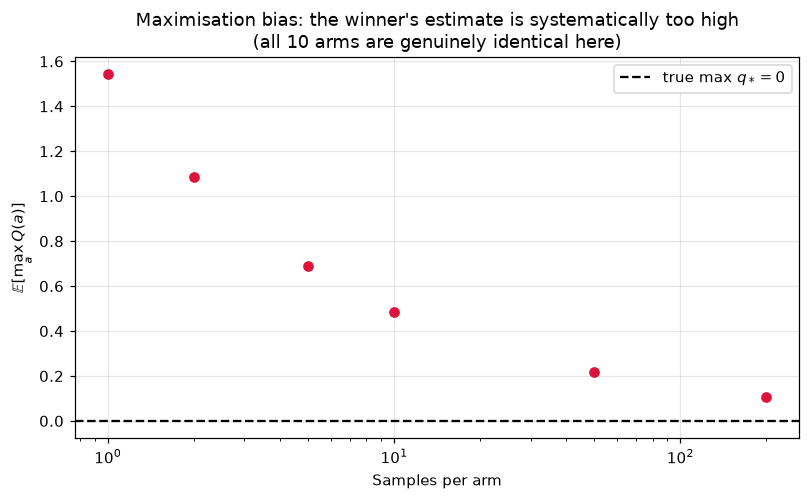

In [9]:
rng = np.random.default_rng(0)
k, trials = 10, 40000
true_q = np.zeros(k)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
for n in [1, 2, 5, 10, 50, 200]:
    est = rng.normal(true_q, 1.0 / np.sqrt(n), size=(trials, k))
    ax.scatter([n], [est.max(axis=1).mean()], color="crimson", zorder=5)
ax.axhline(0, color="k", ls="--", label="true max $q_* = 0$")
ax.set_xscale("log")
ax.set_xlabel("Samples per arm")
ax.set_ylabel(r"$\mathbb{E}[\max_a Q(a)]$")
ax.set_title("Maximisation bias: the winner's estimate is systematically too high\n"
             "(all 10 arms are genuinely identical here)")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

Ten *identical* arms, and the best-looking one always looks better than it is. The bias
shrinks as $\sigma/\sqrt{n}$ — i.e. it decays only as fast as you gather data, which is
another way of saying: exploration does not just find good arms, it *debiases* your
belief about the one you already like.

## Exercise 2.2 (Bandit example) — worth doing by hand

The book gives a 4-armed run with $\varepsilon$-greedy, $Q_1(a) = 0$, sample averages,
and this trace:

$$A_1{=}1, R_1{=}{-}1;\quad A_2{=}2, R_2{=}1;\quad A_3{=}2, R_3{=}{-}2;\quad A_4{=}2, R_4{=}2;\quad A_5{=}3, R_5{=}0$$

Which steps **definitely** involved exploration, and which **possibly** did? Work it
out on paper, then check with the tracer below.

In [10]:
def trace_bandit(actions, rewards, k=4, Q_init=0.0):
    Q = np.full(k, float(Q_init)); N = np.zeros(k, int)
    print(f"{'t':>2} {'A':>2} {'R':>5}  {'Q before':<26} {'greedy set':<14} verdict")
    for t, (a, r) in enumerate(zip(actions, rewards), start=1):
        greedy = set((np.flatnonzero(Q == Q.max()) + 1).tolist())
        if a not in greedy:
            verdict = "DEFINITELY explored"
        elif len(greedy) > 1:
            verdict = "possibly explored (tie)"
        else:
            verdict = "possibly explored (eps landed on greedy)"
        print(f"{t:>2} {a:>2} {r:>5}  {str(np.round(Q,3)):<26} {str(sorted(greedy)):<14} {verdict}")
        N[a-1] += 1
        Q[a-1] += (r - Q[a-1]) / N[a-1]
    print("\nfinal Q:", np.round(Q, 3))

trace_bandit([1, 2, 2, 2, 3], [-1, 1, -2, 2, 0])

 t  A     R  Q before                   greedy set     verdict
 1  1    -1  [0. 0. 0. 0.]              [1, 2, 3, 4]   possibly explored (tie)
 2  2     1  [-1.  0.  0.  0.]          [2, 3, 4]      possibly explored (tie)
 3  2    -2  [-1.  1.  0.  0.]          [2]            possibly explored (eps landed on greedy)
 4  2     2  [-1.  -0.5  0.   0. ]      [3, 4]         DEFINITELY explored
 5  3     0  [-1.     0.333  0.     0.   ] [2]            DEFINITELY explored

final Q: [-1.     0.333  0.     0.   ]


Strictly, exploration is *certain* only when the chosen action was not in the greedy
set. It is *possible* on every step, because $\varepsilon$-greedy can land on the greedy
action by chance — the $\varepsilon/k$ term from 2.1 again.

## Takeaways for 2.2

1. Sample averages converge to $q_*(a)$ **only for actions selected infinitely often**.
2. Greedy freezes nine of ten estimates at a single sample; whatever it commits to was
   likely chosen for being lucky, not good.
3. $\max_a Q(a)$ is an upward-biased estimate of $\max_a q_*(a)$ — maximisation bias.
4. $\varepsilon$-greedy's asymptotic optimal-action rate is capped at
   $1 - \varepsilon + \varepsilon/k$, not 1.

**Next:** run all of this over hundreds of bandit problems and see who actually wins —
Section 2.3.